In [23]:
import zipfile
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, dayofweek, month, avg, stddev, count, sum as _sum, to_timestamp
from pyspark.sql.functions import col, trim, mean, stddev, min, max



In [2]:
zip_path = "/content/halfhourly_dataset.zip"
extract_path = "/content/halfhourly_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted {zip_path} to {extract_path}")

Extracted /content/halfhourly_dataset.zip to /content/halfhourly_dataset


In [8]:
spark = SparkSession.builder \
    .appName("London Smart Meter EDA") \
    .getOrCreate()

print("✅ Spark is ready")

✅ Spark is ready


In [9]:
data_path = "/content/halfhourly_dataset/"

for root, dirs, files in os.walk(data_path):
    for file in files[:5]:
        print(os.path.join(root, file))

/content/halfhourly_dataset/halfhourly_dataset/halfhourly_dataset/block_83.csv
/content/halfhourly_dataset/halfhourly_dataset/halfhourly_dataset/block_82.csv
/content/halfhourly_dataset/halfhourly_dataset/halfhourly_dataset/block_25.csv
/content/halfhourly_dataset/halfhourly_dataset/halfhourly_dataset/block_36.csv
/content/halfhourly_dataset/halfhourly_dataset/halfhourly_dataset/block_35.csv


In [10]:
df = spark.read.option("recursiveFileLookup", "true") \
    .csv("/content/halfhourly_dataset", header=True, inferSchema=True)

df.show(5)

+---------+-------------------+--------------+
|    LCLid|               tstp|energy(kWh/hh)|
+---------+-------------------+--------------+
|MAC000048|2011-12-08 12:30:00|        0.229 |
|MAC000048|2011-12-08 13:00:00|        0.213 |
|MAC000048|2011-12-08 13:30:00|        0.272 |
|MAC000048|2011-12-08 14:00:00|        0.576 |
|MAC000048|2011-12-08 14:30:00|        0.194 |
+---------+-------------------+--------------+
only showing top 5 rows


In [11]:
df = df.dropna()

In [12]:
df = df.withColumn("timestamp", to_timestamp(col("tstp")))

In [13]:
df.printSchema()

root
 |-- LCLid: string (nullable = true)
 |-- tstp: timestamp (nullable = true)
 |-- energy(kWh/hh): string (nullable = true)
 |-- timestamp: timestamp (nullable = true)



In [14]:
df = df.withColumn(
    "energy",
    col("energy(kWh/hh)").cast("double")
)

In [15]:
df = df.dropna(subset=["energy"])

In [16]:
df = df.withColumn("hour", hour("tstp")) \
       .withColumn("day", dayofweek("tstp")) \
       .withColumn("month", month("tstp"))

In [17]:
df.printSchema()
df.show(5)

root
 |-- LCLid: string (nullable = true)
 |-- tstp: timestamp (nullable = true)
 |-- energy(kWh/hh): string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- energy: double (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: integer (nullable = true)

+---------+-------------------+--------------+-------------------+------+----+---+-----+
|    LCLid|               tstp|energy(kWh/hh)|          timestamp|energy|hour|day|month|
+---------+-------------------+--------------+-------------------+------+----+---+-----+
|MAC000048|2011-12-08 12:30:00|        0.229 |2011-12-08 12:30:00| 0.229|  12|  5|   12|
|MAC000048|2011-12-08 13:00:00|        0.213 |2011-12-08 13:00:00| 0.213|  13|  5|   12|
|MAC000048|2011-12-08 13:30:00|        0.272 |2011-12-08 13:30:00| 0.272|  13|  5|   12|
|MAC000048|2011-12-08 14:00:00|        0.576 |2011-12-08 14:00:00| 0.576|  14|  5|   12|
|MAC000048|2011-12-08 14:30:00|        0.194 |2011-12-08

In [18]:
spark.conf.set("spark.sql.ansi.enabled", "false")

In [20]:
files = glob.glob("/content/halfhourly_dataset/**/*.csv", recursive=True)

raw_df = spark.read.csv(files, header=True, inferSchema=False)

df2 = raw_df.filter(
    (col("energy(kWh/hh)").isNotNull()) &
    (trim(col("energy(kWh/hh)")) != "Null")
)

df2 = df2.withColumn(
    "energy",
    trim(col("energy(kWh/hh)")).cast("double")
)

df2.select(
    mean("energy").alias("mean_energy"),
    stddev("energy").alias("stddev_energy"),
    min("energy").alias("min_energy"),
    max("energy").alias("max_energy")
).show()

+-------------------+------------------+----------+----------+
|        mean_energy|     stddev_energy|min_energy|max_energy|
+-------------------+------------------+----------+----------+
|0.21178424342771837|0.2972455529588013|       0.0|10.7609997|
+-------------------+------------------+----------+----------+



In [21]:
df2 = df2.withColumn("timestamp", to_timestamp(col("tstp")))
df2 = df2.withColumn("day", dayofweek(col("timestamp")))

df2.groupBy("day").avg("energy").orderBy("day").show()

+---+-------------------+
|day|        avg(energy)|
+---+-------------------+
|  1|0.22338731692184324|
|  2|0.21142636417975336|
|  3|0.20869386433676812|
|  4|0.20867938366278885|
|  5| 0.2079261991707838|
|  6|0.20871322580168197|
|  7|0.21370601877297504|
+---+-------------------+



In [22]:
df_temp = df2.filter(col("energy(kWh/hh)") != "Null")
df_temp = df_temp.withColumn(
    "energy",
    col("energy(kWh/hh)").cast("double")
)

df_sampled = df_temp.sample(0.01, seed=42)

df_sampled.groupBy("day").avg("energy").orderBy("day").show()

+---+-------------------+
|day|        avg(energy)|
+---+-------------------+
|  1| 0.2221770574152586|
|  2|0.21127772087295646|
|  3|0.20873076970587606|
|  4|0.20902635971192468|
|  5|0.20860528565776043|
|  6|0.20875936800374434|
|  7|0.21384481612314044|
+---+-------------------+



In [24]:
df2 = df2.withColumn("timestamp", to_timestamp(col("tstp")))
df2 = df2.withColumn("hour", hour(col("timestamp")))
df2.groupBy("hour").avg("energy").orderBy("hour").show()

+----+-------------------+
|hour|        avg(energy)|
+----+-------------------+
|   0|0.17425251778565992|
|   1| 0.1449855340581243|
|   2|0.12478344171592781|
|   3|0.11563761044993975|
|   4|0.11448760259893954|
|   5| 0.1257403430539485|
|   6| 0.1572677314214662|
|   7|0.19273803182657162|
|   8|0.21349205582377376|
|   9|0.21578596577574607|
|  10|0.21397272122220556|
|  11|0.21418238628687766|
|  12|  0.216393449073098|
|  13|0.21435518773091644|
|  14|0.21050705984544202|
|  15|0.21620475275585258|
|  16|0.24141534347873436|
|  17|0.28124610564842445|
|  18| 0.3120675149093661|
|  19| 0.3208646485277374|
+----+-------------------+
only showing top 20 rows


In [25]:
df_sample = df2.sample(0.01, seed=42)
stats = df_sample.select(mean("energy"), stddev("energy")).collect()[0]
df_sample.filter(col("energy") > stats[0] + 3*stats[1]).show()

+---------+--------------------+--------------+---------+-------------------+---+----+
|    LCLid|                tstp|energy(kWh/hh)|   energy|          timestamp|day|hour|
+---------+--------------------+--------------+---------+-------------------+---+----+
|MAC000048|2012-02-22 22:30:...|    1.2079999 |1.2079999|2012-02-22 22:30:00|  4|  22|
|MAC000048|2013-01-29 21:00:...|        1.271 |    1.271|2013-01-29 21:00:00|  3|  21|
|MAC000048|2013-03-16 00:00:...|        1.123 |    1.123|2013-03-16 00:00:00|  7|   0|
|MAC000064|2012-01-02 08:30:...|        1.382 |    1.382|2012-01-02 08:30:00|  2|   8|
|MAC000064|2012-01-09 17:00:...|        1.652 |    1.652|2012-01-09 17:00:00|  2|  17|
|MAC000064|2012-02-06 17:30:...|    1.4529999 |1.4529999|2012-02-06 17:30:00|  2|  17|
|MAC000064|2012-02-13 17:30:...|    1.2690001 |1.2690001|2012-02-13 17:30:00|  2|  17|
|MAC000064|2012-03-18 11:30:...|    1.1210001 |1.1210001|2012-03-18 11:30:00|  1|  11|
|MAC000064|2012-06-23 19:00:...|    1.12100

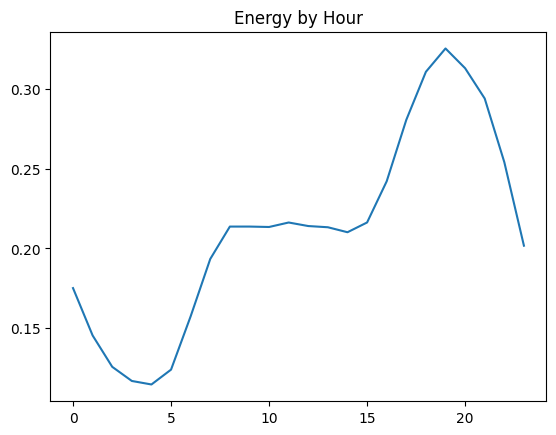

In [26]:
hourly = df_sample.groupBy("hour").avg("energy").orderBy("hour").toPandas()
plt.plot(hourly["hour"], hourly["avg(energy)"])
plt.title("Energy by Hour")
plt.show()

In [27]:
df2 = df2.withColumn("month", month(col("timestamp")))
df2.groupBy("month").avg("energy").orderBy("month").show()

+-----+-------------------+
|month|        avg(energy)|
+-----+-------------------+
|    1| 0.2536800930479084|
|    2| 0.2486818132072879|
|    3|0.24899320451615514|
|    4|0.21159497865780066|
|    5| 0.1859989853115197|
|    6|0.17628668582282112|
|    7|0.17014356411206583|
|    8|0.16631880555533907|
|    9|0.18281551202287896|
|   10| 0.2051737217341158|
|   11| 0.2348554834303256|
|   12|  0.252497465088078|
+-----+-------------------+



In [28]:
df_sample.select("energy").describe().show()

+-------+-------------------+
|summary|             energy|
+-------+-------------------+
|  count|            1677336|
|   mean| 0.2118587218058872|
| stddev|0.29789744985339456|
|    min|                0.0|
|    max|          8.2220001|
+-------+-------------------+



In [29]:
stats = df2.select(mean("energy").alias("mean"), stddev("energy").alias("std")).collect()[0]
mean_val = stats["mean"]
std_val = stats["std"]

outliers = df2.filter(col("energy") > mean_val + 3 * std_val)
outliers.show(10)
print("Number of outliers:", outliers.count())

+---------+--------------------+--------------+---------+-------------------+---+----+-----+
|    LCLid|                tstp|energy(kWh/hh)|   energy|          timestamp|day|hour|month|
+---------+--------------------+--------------+---------+-------------------+---+----+-----+
|MAC000048|2011-12-10 10:30:...|        1.215 |    1.215|2011-12-10 10:30:00|  7|  10|   12|
|MAC000048|2011-12-10 11:00:...|        1.322 |    1.322|2011-12-10 11:00:00|  7|  11|   12|
|MAC000048|2011-12-11 12:00:...|    2.0009999 |2.0009999|2011-12-11 12:00:00|  1|  12|   12|
|MAC000048|2011-12-11 12:30:...|        1.316 |    1.316|2011-12-11 12:30:00|  1|  12|   12|
|MAC000048|2011-12-15 09:30:...|    1.2869999 |1.2869999|2011-12-15 09:30:00|  5|   9|   12|
|MAC000048|2011-12-16 01:30:...|        1.551 |    1.551|2011-12-16 01:30:00|  6|   1|   12|
|MAC000048|2011-12-16 17:30:...|        1.233 |    1.233|2011-12-16 17:30:00|  6|  17|   12|
|MAC000048|2011-12-16 18:00:...|         1.35 |     1.35|2011-12-16 18

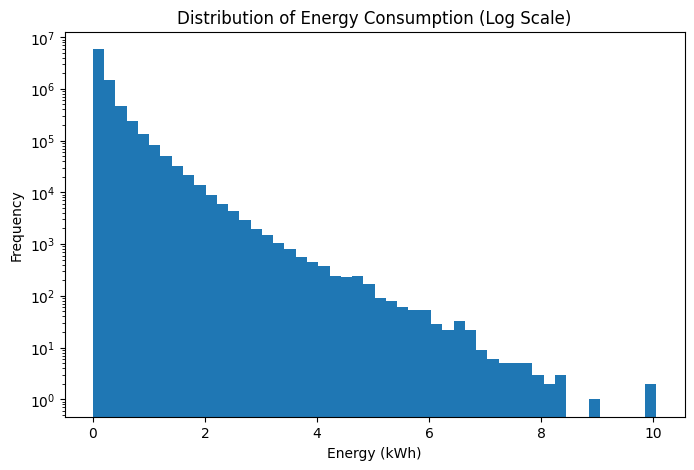

In [32]:
#Distribution of Energy Consumption
pdf = df2.sample(0.05).select("energy").toPandas()

plt.figure(figsize=(8,5))
plt.hist(pdf["energy"], bins=50)
plt.yscale('log')
plt.title("Distribution of Energy Consumption (Log Scale)")
plt.xlabel("Energy (kWh)")
plt.ylabel("Frequency")
plt.show()

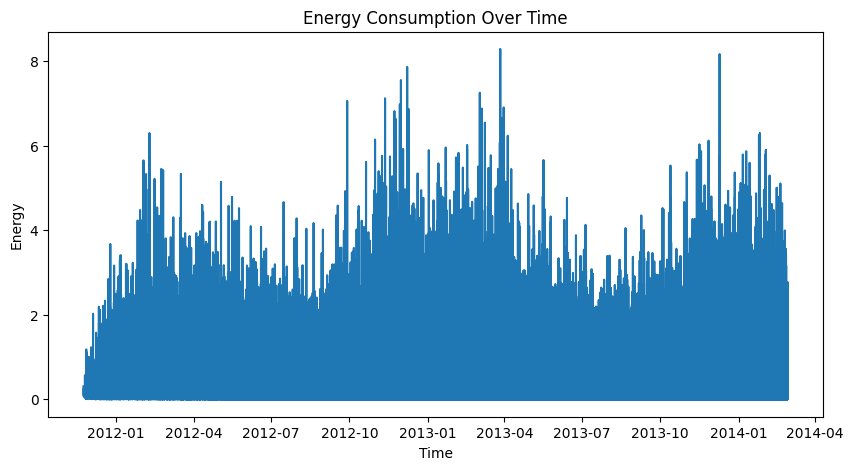

In [33]:
#Energy Consumption over time
pdf = df2.sample(0.01).select("timestamp", "energy").toPandas()

pdf = pdf.sort_values("timestamp")

plt.figure(figsize=(10,5))
plt.plot(pdf["timestamp"], pdf["energy"])

plt.title("Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.show()

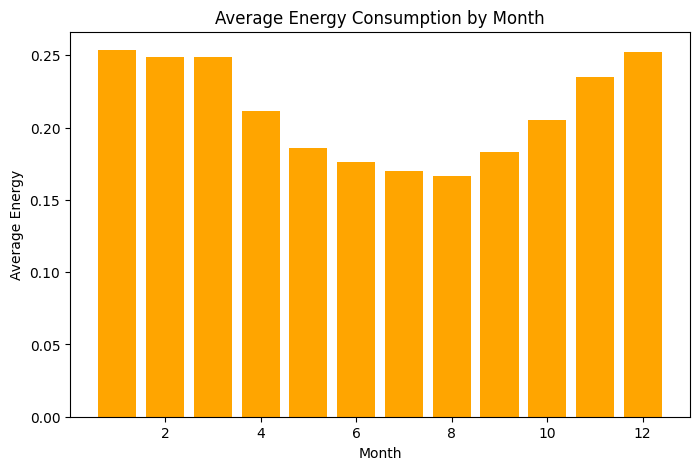

In [ ]:
#Average consumption by month
monthly = df2.groupBy("month").avg("energy").orderBy("month").toPandas()

plt.figure(figsize=(8,5))
plt.bar(monthly["month"], monthly["avg(energy)"], color="orange")

plt.title("Average Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Energy")
plt.show()

# models Building

In [34]:
from pyspark.sql.functions import hour, dayofweek, month, to_timestamp, col
from pyspark.ml.feature import VectorAssembler

df2 = df2.withColumn("timestamp", to_timestamp(col("tstp")))
df2 = df2.withColumn("hour", hour("timestamp")) \
         .withColumn("day", dayofweek("timestamp")) \
         .withColumn("month", month("timestamp"))
df2 = df2.dropna(subset=["energy", "hour", "day", "month"])

features = ["hour", "day", "month"]
assembler = VectorAssembler(inputCols=features, outputCol="features")
ml_data = assembler.transform(df2).select("features", "energy")

ml_data = ml_data.sample(0.01, seed=42)
ml_data = ml_data.cache()
train_data, test_data = ml_data.randomSplit([0.8, 0.2], seed=42)



##Linear Regression

In [35]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="energy")
lr_model = lr.fit(train_data)

lr_pred = lr_model.transform(test_data)

## Random Forest

In [36]:
from pyspark.ml.regression import RandomForestRegressor
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="energy",
    numTrees=10,
    maxDepth=4,
    seed=42
)
rf_model = rf.fit(train_data)
rf_pred = rf_model.transform(test_data)

## Gradient Boosted Trees(GBT)

In [37]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="energy",
    maxIter=10,
    maxDepth=3,
    seed=42
)
gbt_model = gbt.fit(train_data)
gbt_pred = gbt_model.transform(test_data)

##Evaluate models

In [38]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(labelCol="energy", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="energy", predictionCol="prediction", metricName="r2")
evaluator_mae = RegressionEvaluator(labelCol="energy", predictionCol="prediction", metricName="mae")

In [39]:
# Linear Regression Metrics
lr_rmse = evaluator_rmse.evaluate(lr_pred)
lr_r2 = evaluator_r2.evaluate(lr_pred)
lr_mae = evaluator_mae.evaluate(lr_pred)

In [40]:
#Random Forest Metrics
rf_rmse = evaluator_rmse.evaluate(rf_pred)
rf_r2 = evaluator_r2.evaluate(rf_pred)
rf_mae = evaluator_mae.evaluate(rf_pred)

In [41]:
# GBT Metrics
gbt_rmse = evaluator_rmse.evaluate(gbt_pred)
gbt_r2 = evaluator_r2.evaluate(gbt_pred)
gbt_mae = evaluator_mae.evaluate(gbt_pred)

In [42]:
feature_names = ["hour", "day", "month"]
importances = gbt_model.featureImportances.toArray()
for i in range(len(feature_names)):
    print(f"{feature_names[i]}: {importances[i]:.4f}")

hour: 0.4974
day: 0.0077
month: 0.4950


In [43]:
results = spark.createDataFrame([
    ("Linear Regression", lr_rmse, lr_mae, lr_r2),
    ("Random Forest", rf_rmse, rf_mae, rf_r2),
    ("GBT", gbt_rmse, gbt_mae, gbt_r2)
], ["Model", "RMSE", "MAE", "R2"])

results.show()

+-----------------+-------------------+-------------------+--------------------+
|            Model|               RMSE|                MAE|                  R2|
+-----------------+-------------------+-------------------+--------------------+
|Linear Regression| 0.2912286659030311| 0.1686577122839404|0.030597419891686184|
|    Random Forest|0.28881873140908937|0.16691693334832608|0.046574766255362166|
|              GBT|0.28742000474185686|0.16516761436975452| 0.05578713331944385|
+-----------------+-------------------+-------------------+--------------------+



In [44]:
import builtins

results_dict = {
    "Linear Regression": lr_rmse,
    "Random Forest": rf_rmse,
    "GBT": gbt_rmse
}

best_model = builtins.min(results_dict, key=results_dict.get)
worst_model = builtins.max(results_dict, key=results_dict.get)

print("Best Model:", best_model, "| RMSE:", results_dict[best_model])
print("Worst Model:", worst_model, "| RMSE:", results_dict[worst_model])

Best Model: GBT | RMSE: 0.28742000474185686
Worst Model: Linear Regression | RMSE: 0.2912286659030311


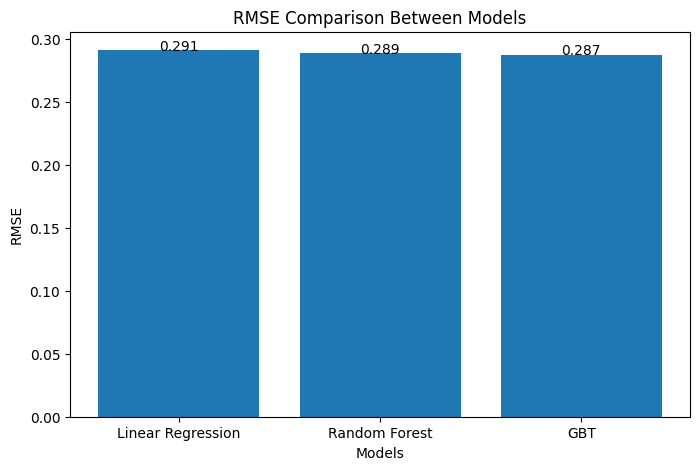

In [48]:
models = ["Linear Regression", "Random Forest", "GBT"]
rmse_values = [lr_rmse, rf_rmse, gbt_rmse]
plt.figure(figsize=(8,5))
plt.bar(models, rmse_values)
plt.title("RMSE Comparison Between Models")
plt.xlabel("Models")
plt.ylabel("RMSE")
for i in range(len(models)):
    plt.text(i, rmse_values[i], round(rmse_values[i], 3), ha='center')
plt.show()



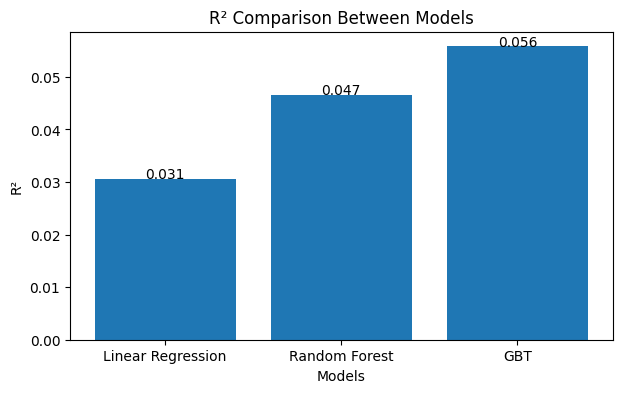

In [49]:
models = ["Linear Regression", "Random Forest", "GBT"]
r2_values = [lr_r2, rf_r2, gbt_r2]

plt.figure(figsize=(7,4))
plt.bar(models, r2_values)
plt.title("R² Comparison Between Models")
plt.xlabel("Models")
plt.ylabel("R²")

for i in range(len(models)):
    plt.text(i, r2_values[i], round(r2_values[i], 3), ha='center')

plt.show()

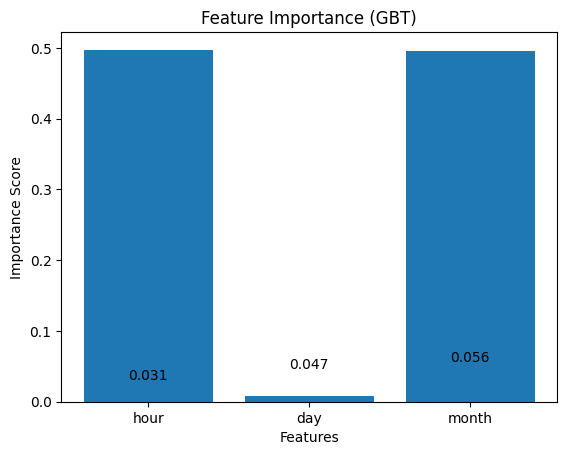

In [52]:
plt.bar(feature_names, importances)
plt.title("Feature Importance (GBT)")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.savefig("feature_importance.png")
for i in range(len(models)):
    plt.text(i, r2_values[i], round(r2_values[i], 3), ha='center')

plt.show()